# RiskGuard — IEEE-CIS Fraud Detection
## Notebook 01: Data Understanding & Exploratory Fraud Analysis (EDA)

> **Objective**: Understand the IEEE-CIS transaction and identity data, investigate the characteristics of fraudulent transactions, identify important data-quality patterns, and establish justified directions for Notebook 2 (Preprocessing & Feature Engineering) without fitting predictive models.

---
## 1. Environment & Data Loading
Configure reproducible settings, setup output directories, and load raw datasets using Polars.

In [1]:
import sys
import os
import datetime
import warnings
from pathlib import Path

# Core Data Processing Engine
import polars as pl

# Scientific Computing & Interoperability
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Global Warning Configuration
warnings.filterwarnings('ignore')

# Polars Display Configuration
pl.Config.set_tbl_rows(15)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(50)

# Matplotlib / Seaborn Aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica', 'Arial', 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#EAEAEA'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['figure.titlesize'] = 13
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

# Consistent Color Palette
COLOR_LEGIT = '#2B5C8F'     # Navy Blue for Legitimate (Class 0)
COLOR_FRAUD = '#D9381E'     # Crimson Red for Fraud (Class 1)
COLOR_PRIMARY = '#1F77B4'   # Steel Blue for general distributions
COLOR_ACCENT = '#FF7F0E'    # Orange Accent
PALETTE_PAIR = [COLOR_LEGIT, COLOR_FRAUD]

# Directory Setup & Figure Auto-Save Helper
RANDOM_SEED = 42
# Directory Architecture Configuration (Resilient to project root and Notebooks/ context)
BASE_DIR = Path('..') if Path('../Data').exists() else Path('.')
DATA_DIR = BASE_DIR / 'Data'
RAW_DIR = DATA_DIR / 'raw' if (DATA_DIR / 'raw').exists() else BASE_DIR / 'raw'
OUTPUT_DIR = BASE_DIR / 'output'
FIG_DIR = OUTPUT_DIR / 'figures'
REPORTS_DIR = OUTPUT_DIR / 'reports'
TABLES_DIR = OUTPUT_DIR / 'tables'

FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig: plt.Figure, filename: str):
    filepath = FIG_DIR / filename
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"[Saved Plot] -> {filepath}")

print(f"Environment initialized. Figures saved to: {FIG_DIR.resolve()}")

Environment initialized. Figures saved to: C:\Users\hiten\Documents\RP\output\figures


### 1.1 Discover Raw Dataset Files
Verify existence, readability, and file sizes for all raw IEEE-CIS CSV files.

In [2]:
expected_files = [
    'train_transaction.csv',
    'train_identity.csv',
    'test_transaction.csv',
    'test_identity.csv',
    'sample_submission.csv'
]

file_records = []
for fname in expected_files:
    fpath = RAW_DIR / fname
    exists = fpath.exists()
    size_mb = (fpath.stat().st_size / (1024 ** 2)) if exists else 0.0
    file_records.append({
        'File Name': fname,
        'Size (MB)': round(size_mb, 2),
        'Exists': '✓' if exists else '✗'
    })

df_files = pl.DataFrame(file_records)
print(df_files)

shape: (5, 3)
┌───────────────────────┬───────────┬────────┐
│ File Name             ┆ Size (MB) ┆ Exists │
│ ---                   ┆ ---       ┆ ---    │
│ str                   ┆ f64       ┆ str    │
╞═══════════════════════╪═══════════╪════════╡
│ train_transaction.csv ┆ 651.69    ┆ ✓      │
│ train_identity.csv    ┆ 25.3      ┆ ✓      │
│ test_transaction.csv  ┆ 584.79    ┆ ✓      │
│ test_identity.csv     ┆ 24.6      ┆ ✓      │
│ sample_submission.csv ┆ 5.8       ┆ ✓      │
└───────────────────────┴───────────┴────────┘


### 1.2 Load Raw Datasets with Polars
Ingest raw transaction and identity tables into memory with multithreaded Polars.

In [3]:
print("Loading raw datasets with Polars...")

train_tx = pl.read_csv(RAW_DIR / 'train_transaction.csv', infer_schema_length=10000, null_values=['', 'NA', 'NaN'])
train_id = pl.read_csv(RAW_DIR / 'train_identity.csv', infer_schema_length=10000, null_values=['', 'NA', 'NaN'])
test_tx = pl.read_csv(RAW_DIR / 'test_transaction.csv', infer_schema_length=10000, null_values=['', 'NA', 'NaN'])
test_id = pl.read_csv(RAW_DIR / 'test_identity.csv', infer_schema_length=10000, null_values=['', 'NA', 'NaN'])

# Loading summary table
loading_summary = pl.DataFrame([
    {
        'Dataset': 'Train Transaction',
        'Rows': f"{train_tx.height:,}",
        'Columns': train_tx.width,
        'Estimated Memory (MB)': round(train_tx.estimated_size() / (1024 ** 2), 2)
    },
    {
        'Dataset': 'Train Identity',
        'Rows': f"{train_id.height:,}",
        'Columns': train_id.width,
        'Estimated Memory (MB)': round(train_id.estimated_size() / (1024 ** 2), 2)
    },
    {
        'Dataset': 'Test Transaction',
        'Rows': f"{test_tx.height:,}",
        'Columns': test_tx.width,
        'Estimated Memory (MB)': round(test_tx.estimated_size() / (1024 ** 2), 2)
    },
    {
        'Dataset': 'Test Identity',
        'Rows': f"{test_id.height:,}",
        'Columns': test_id.width,
        'Estimated Memory (MB)': round(test_id.estimated_size() / (1024 ** 2), 2)
    }
])

print("\n=== Dataset Loading Summary ===")
print(loading_summary)

Loading raw datasets with Polars...



=== Dataset Loading Summary ===
shape: (4, 4)
┌───────────────────┬─────────┬─────────┬───────────────────────┐
│ Dataset           ┆ Rows    ┆ Columns ┆ Estimated Memory (MB) │
│ ---               ┆ ---     ┆ ---     ┆ ---                   │
│ str               ┆ str     ┆ i64     ┆ f64                   │
╞═══════════════════╪═════════╪═════════╪═══════════════════════╡
│ Train Transaction ┆ 590,540 ┆ 394     ┆ 1747.09               │
│ Train Identity    ┆ 144,233 ┆ 41      ┆ 37.91                 │
│ Test Transaction  ┆ 506,691 ┆ 393     ┆ 1495.07               │
│ Test Identity     ┆ 141,907 ┆ 41      ┆ 37.03                 │
└───────────────────┴─────────┴─────────┴───────────────────────┘


---
## 2. Basic Data Understanding
Inspect raw sample rows, table dimensions, summary statistics, relational keys, and feature group categories.

In [4]:
print("--- Train Transaction Sample (First 5 Rows, Selected Columns) ---")
print(train_tx.select(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card4', 'card6', 'P_emaildomain', 'addr1', 'C1', 'D1']).head(5))

print("\n--- Train Identity Sample (First 5 Rows, Selected Columns) ---")
print(train_id.select(['TransactionID', 'id_01', 'id_02', 'id_12', 'id_15', 'id_30', 'id_31', 'DeviceType', 'DeviceInfo']).head(5))

--- Train Transaction Sample (First 5 Rows, Selected Columns) ---
shape: (5, 12)
┌────────┬────────┬────────┬────────┬────────┬───────┬───────┬───────┬───────┬───────┬─────┬───────┐
│ Transa ┆ isFrau ┆ Transa ┆ Transa ┆ Produc ┆ card1 ┆ card4 ┆ card6 ┆ P_ema ┆ addr1 ┆ C1  ┆ D1    │
│ ctionI ┆ d      ┆ ctionD ┆ ctionA ┆ tCD    ┆ ---   ┆ ---   ┆ ---   ┆ ildom ┆ ---   ┆ --- ┆ ---   │
│ D      ┆ ---    ┆ T      ┆ mt     ┆ ---    ┆ i64   ┆ str   ┆ str   ┆ ain   ┆ f64   ┆ f64 ┆ f64   │
│ ---    ┆ i64    ┆ ---    ┆ ---    ┆ str    ┆       ┆       ┆       ┆ ---   ┆       ┆     ┆       │
│ i64    ┆        ┆ i64    ┆ f64    ┆        ┆       ┆       ┆       ┆ str   ┆       ┆     ┆       │
╞════════╪════════╪════════╪════════╪════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═════╪═══════╡
│ 298700 ┆ 0      ┆ 86400  ┆ 68.5   ┆ W      ┆ 13926 ┆ disco ┆ credi ┆ null  ┆ 315.0 ┆ 1.0 ┆ 14.0  │
│ 0      ┆        ┆        ┆        ┆        ┆       ┆ ver   ┆ t     ┆       ┆       ┆     ┆       │
│ 298700 ┆

### 2.1 Compact Numerical Describe Overview
Inspect central tendencies, spreads, and quartiles across representative numerical attributes.

In [5]:
desc_cols = ['TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'D1', 'D15']
print("=== Selected Numerical Features Summary (describe) ===")
print(train_tx.select(desc_cols).describe())

=== Selected Numerical Features Summary (describe) ===
shape: (9, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ Transactio ┆ dist1      ┆ dist2     ┆ C1        ┆ C2        ┆ D1        ┆ D15       │
│ ---        ┆ nAmt       ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str        ┆ ---        ┆ f64        ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│            ┆ f64        ┆            ┆           ┆           ┆           ┆           ┆           │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 590540.0   ┆ 238269.0   ┆ 37627.0   ┆ 590540.0  ┆ 590540.0  ┆ 589271.0  ┆ 501427.0  │
│ null_count ┆ 0.0        ┆ 352271.0   ┆ 552913.0  ┆ 0.0       ┆ 0.0       ┆ 1269.0    ┆ 89113.0   │
│ mean       ┆ 135.027176 ┆ 118.50218  ┆ 231.85542 ┆ 14.092458 ┆ 15.269734 ┆ 94.347568 ┆ 163.74457 │
│            ┆        

### 2.2 Table Shapes & Relational Linkage
The transaction table is the primary analytical table; the identity table is an auxiliary sidecar table linked via `TransactionID`.

In [6]:
# Verify identity coverage in Train and Test
train_id_cov = (train_tx.select('TransactionID').join(train_id.select('TransactionID').with_columns(pl.lit(1).alias('has_id')), on='TransactionID', how='left'))
test_id_cov = (test_tx.select('TransactionID').join(test_id.select('TransactionID').with_columns(pl.lit(1).alias('has_id')), on='TransactionID', how='left'))

train_cov_pct = (train_id_cov['has_id'].drop_nulls().len() / train_tx.height) * 100
test_cov_pct = (test_id_cov['has_id'].drop_nulls().len() / test_tx.height) * 100

print(f"Identity Record Coverage in Train: {train_id_cov['has_id'].drop_nulls().len():,} / {train_tx.height:,} ({train_cov_pct:.2f}%)")
print(f"Identity Record Coverage in Test:  {test_id_cov['has_id'].drop_nulls().len():,} / {test_tx.height:,} ({test_cov_pct:.2f}%)")

Identity Record Coverage in Train: 144,233 / 590,540 (24.42%)
Identity Record Coverage in Test:  141,907 / 506,691 (28.01%)


### 2.3 Feature Group Taxonomy
The 434 features map across 10 distinct operational groups: IDs/Target (2), Core (3), Cards (6), Address/Distance (4), Emails (2), Match M1-M9 (9), Counters C1-C14 (14), Timedeltas D1-D15 (15), Vesta V1-V339 (339), and Identity/Device (40).

In [7]:
taxonomy_data = [
    {'Feature Group': 'IDs / Target', 'Count': 2, 'Description': 'Primary key (TransactionID) and ground truth label (isFraud)'},
    {'Feature Group': 'Transaction Core', 'Count': 3, 'Description': 'TransactionDT, TransactionAmt, ProductCD'},
    {'Feature Group': 'Card Specifications', 'Count': 6, 'Description': 'card1 - card6 (network, issuer bank, card type, tier)'},
    {'Feature Group': 'Address & Distance', 'Count': 4, 'Description': 'addr1, addr2, dist1, dist2 (billing/shipping regions & distance)'},
    {'Feature Group': 'Email Domains', 'Count': 2, 'Description': 'P_emaildomain, R_emaildomain (purchaser and recipient domains)'},
    {'Feature Group': 'Match Features (M-Block)', 'Count': 9, 'Description': 'M1 - M9 (address, card, name verification match flags)'},
    {'Feature Group': 'Count Features (C-Block)', 'Count': 14, 'Description': 'C1 - C14 (frequency counters of associated payment entities)'},
    {'Feature Group': 'Time Deltas (D-Block)', 'Count': 15, 'Description': 'D1 - D15 (timedeltas in days since previous transaction/event)'},
    {'Feature Group': 'Vesta Features (V-Block)', 'Count': 339, 'Description': 'V1 - V339 (engineered transaction scoring sub-blocks)'},
    {'Feature Group': 'Identity & Device', 'Count': 40, 'Description': 'id_01 - id_38, DeviceType, DeviceInfo (authentication fingerprint)'},
]

df_taxonomy = pl.DataFrame(taxonomy_data)
print("=== Feature Group Taxonomy (434 Total Features) ===")
print(df_taxonomy)
print(f"\nTotal Features Sum: {df_taxonomy['Count'].sum()}")

=== Feature Group Taxonomy (434 Total Features) ===
shape: (10, 3)
┌──────────────────────────┬───────┬─────────────────────────────────────────────────────┐
│ Feature Group            ┆ Count ┆ Description                                         │
│ ---                      ┆ ---   ┆ ---                                                 │
│ str                      ┆ i64   ┆ str                                                 │
╞══════════════════════════╪═══════╪═════════════════════════════════════════════════════╡
│ IDs / Target             ┆ 2     ┆ Primary key (TransactionID) and ground truth label… │
│ Transaction Core         ┆ 3     ┆ TransactionDT, TransactionAmt, ProductCD            │
│ Card Specifications      ┆ 6     ┆ card1 - card6 (network, issuer bank, card type, ti… │
│ Address & Distance       ┆ 4     ┆ addr1, addr2, dist1, dist2 (billing/shipping regio… │
│ Email Domains            ┆ 2     ┆ P_emaildomain, R_emaildomain (purchaser and recipi… │
│ Match Features (M-Blo

---
## 3. Data Quality Analysis
Profile data types, missing value distributions across columns and groups, uniqueness, and categorical cardinality.

In [8]:
def get_dtype_summary(df: pl.DataFrame, name: str) -> pl.DataFrame:
    dtype_counts = {}
    for dt in df.dtypes:
        s = str(dt)
        dtype_counts[s] = dtype_counts.get(s, 0) + 1
    return pl.DataFrame([{'Dataset': name, 'Data Type': k, 'Column Count': v} for k, v in dtype_counts.items()])

df_dtypes = pl.concat([
    get_dtype_summary(train_tx, 'Train Transaction'),
    get_dtype_summary(train_id, 'Train Identity')
])

print("=== Data Type Breakdown ===")
print(df_dtypes)

=== Data Type Breakdown ===
shape: (6, 3)
┌───────────────────┬───────────┬──────────────┐
│ Dataset           ┆ Data Type ┆ Column Count │
│ ---               ┆ ---       ┆ ---          │
│ str               ┆ str       ┆ i64          │
╞═══════════════════╪═══════════╪══════════════╡
│ Train Transaction ┆ Int64     ┆ 4            │
│ Train Transaction ┆ Float64   ┆ 376          │
│ Train Transaction ┆ String    ┆ 14           │
│ Train Identity    ┆ Int64     ┆ 1            │
│ Train Identity    ┆ Float64   ┆ 23           │
│ Train Identity    ┆ String    ┆ 17           │
└───────────────────┴───────────┴──────────────┘


### 3.1 Column Missingness & Top-20 Missing Features
Identify the most incomplete features in the transaction table.

--- Top 20 Most Missing Features in Transaction Table ---
shape: (20, 3)
┌─────────┬───────────────┬─────────────┐
│ feature ┆ missing_count ┆ missing_pct │
│ ---     ┆ ---           ┆ ---         │
│ str     ┆ i64           ┆ f64         │
╞═════════╪═══════════════╪═════════════╡
│ dist2   ┆ 552913        ┆ 93.63       │
│ D7      ┆ 551623        ┆ 93.41       │
│ D13     ┆ 528588        ┆ 89.51       │
│ D14     ┆ 528353        ┆ 89.47       │
│ D12     ┆ 525823        ┆ 89.04       │
│ D6      ┆ 517353        ┆ 87.61       │
│ D8      ┆ 515614        ┆ 87.31       │
│ D9      ┆ 515614        ┆ 87.31       │
│ …       ┆ …             ┆ …           │
│ V143    ┆ 508589        ┆ 86.12       │
│ V144    ┆ 508589        ┆ 86.12       │
│ V145    ┆ 508589        ┆ 86.12       │
│ V146    ┆ 508595        ┆ 86.12       │
│ V147    ┆ 508595        ┆ 86.12       │
│ V148    ┆ 508595        ┆ 86.12       │
│ V149    ┆ 508595        ┆ 86.12       │
└─────────┴───────────────┴─────────────┘


[Saved Plot] -> output\figures\fig01_top20_missing_features.png


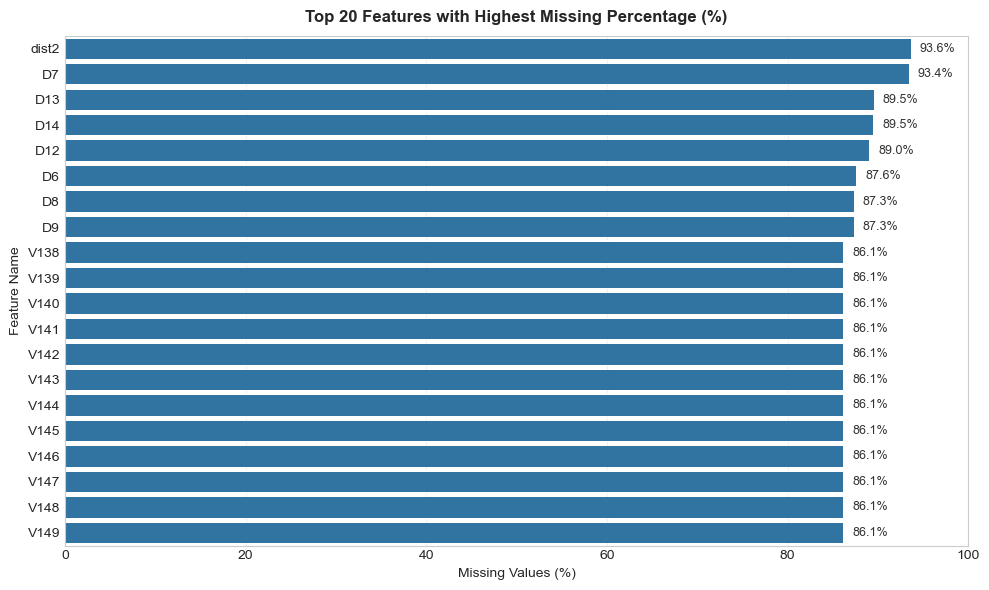

In [9]:
# Calculate missing rates for train_transaction
null_counts = train_tx.null_count()
missing_tx = []
for col in train_tx.columns:
    if col == 'isFraud':
        continue
    c = null_counts[col][0]
    pct = (c / train_tx.height) * 100
    missing_tx.append({'feature': col, 'missing_count': c, 'missing_pct': round(pct, 2)})

df_missing_tx = pl.DataFrame(missing_tx).sort('missing_pct', descending=True)

print("--- Top 20 Most Missing Features in Transaction Table ---")
print(df_missing_tx.head(20))

# Plot top 20 missing features
fig, ax = plt.subplots(figsize=(10, 6))
top20_miss_pd = df_missing_tx.head(20).to_pandas()
sns.barplot(data=top20_miss_pd, y='feature', x='missing_pct', color=COLOR_PRIMARY, ax=ax)
ax.set_title('Top 20 Features with Highest Missing Percentage (%)', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Missing Values (%)', fontsize=10)
ax.set_ylabel('Feature Name', fontsize=10)
ax.set_xlim(0, 100)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    ax.annotate(f"{width:.1f}%", (width + 1, p.get_y() + p.get_height() / 2),
                va='center', fontsize=9, color='#333333')

plt.tight_layout()
save_fig(fig, 'fig01_top20_missing_features.png')
plt.show()

### 3.2 Missingness Distribution by Feature Group
Summarize missing value concentrations across operational feature categories.

In [10]:
def get_feature_group(col: str) -> str:
    if col in ['TransactionID', 'isFraud']:
        return 'ID & Target'
    elif col in ['TransactionDT', 'TransactionAmt', 'ProductCD']:
        return 'Transaction Core'
    elif col.startswith('card'):
        return 'Card (card1-6)'
    elif col.startswith('addr') or col.startswith('dist'):
        return 'Address & Distance'
    elif 'emaildomain' in col:
        return 'Email Domains'
    elif col.startswith('M'):
        return 'M-Block (Matches)'
    elif col.startswith('C'):
        return 'C-Block (Counters)'
    elif col.startswith('D'):
        return 'D-Block (Timedeltas)'
    elif col.startswith('V'):
        return 'V-Block (Vesta Rich)'
    elif col.startswith('id_') or col.startswith('id-') or col in ['DeviceType', 'DeviceInfo']:
        return 'Identity & Device'
    return 'Other'

group_missing = (
    df_missing_tx
    .with_columns(pl.col('feature').map_elements(get_feature_group, return_dtype=pl.String).alias('feature_group'))
    .group_by('feature_group')
    .agg([
        pl.col('feature').count().alias('feature_count'),
        pl.col('missing_pct').mean().round(2).alias('avg_missing_pct'),
        pl.col('missing_pct').min().round(2).alias('min_missing_pct'),
        pl.col('missing_pct').max().round(2).alias('max_missing_pct')
    ])
    .sort('avg_missing_pct', descending=True)
)

print("=== Missingness Summary by Feature Group ===")
print(group_missing)

=== Missingness Summary by Feature Group ===
shape: (9, 5)
┌──────────────────────┬───────────────┬─────────────────┬─────────────────┬─────────────────┐
│ feature_group        ┆ feature_count ┆ avg_missing_pct ┆ min_missing_pct ┆ max_missing_pct │
│ ---                  ┆ ---           ┆ ---             ┆ ---             ┆ ---             │
│ str                  ┆ u32           ┆ f64             ┆ f64             ┆ f64             │
╞══════════════════════╪═══════════════╪═════════════════╪═════════════════╪═════════════════╡
│ D-Block (Timedeltas) ┆ 15            ┆ 58.15           ┆ 0.21            ┆ 93.41           │
│ M-Block (Matches)    ┆ 9             ┆ 49.92           ┆ 28.68           ┆ 59.35           │
│ Email Domains        ┆ 2             ┆ 46.37           ┆ 15.99           ┆ 76.75           │
│ Address & Distance   ┆ 4             ┆ 43.88           ┆ 11.13           ┆ 93.63           │
│ V-Block (Vesta Rich) ┆ 339           ┆ 43.04           ┆ 0.0             ┆ 86.12    

### 3.3 Data Integrity & Validity Checks
Validate primary key uniqueness supporting a one-to-one sidecar relationship, target bounds, and non-negative amounts.

In [11]:
# Primary Key Uniqueness
tx_id_unique = train_tx['TransactionID'].n_unique() == train_tx.height
id_id_unique = train_id['TransactionID'].n_unique() == train_id.height

# Basic Validity Sanity Checks
neg_amt_count = train_tx.filter(pl.col('TransactionAmt') < 0).height
invalid_target_count = train_tx.filter(~pl.col('isFraud').is_in([0, 1])).height

print("=== Data Integrity Checks ===")
print(f"TransactionID unique in train_transaction: {tx_id_unique} ({train_tx.height:,} rows)")
print(f"TransactionID unique in train_identity:    {id_id_unique} ({train_id.height:,} rows; confirms 1-to-1 auxiliary sidecar)")
print(f"Transactions with Negative Amount (Amt < 0):       {neg_amt_count}")
print(f"Transactions with Invalid Target (not in [0, 1]):   {invalid_target_count}")

=== Data Integrity Checks ===
TransactionID unique in train_transaction: True (590,540 rows)
TransactionID unique in train_identity:    True (144,233 rows; confirms 1-to-1 auxiliary sidecar)
Transactions with Negative Amount (Amt < 0):       0
Transactions with Invalid Target (not in [0, 1]):   0


### 3.4 Categorical Feature Cardinality
Audit unique modality counts across categorical attributes to identify encoding requirements.

In [12]:
cat_cols = ['ProductCD', 'card4', 'card6', 'DeviceType', 'P_emaildomain', 'R_emaildomain', 'DeviceInfo', 'card1', 'addr1']
card_records = []

for col in cat_cols:
    if col in train_tx.columns:
        s = train_tx[col]
    elif col in train_id.columns:
        s = train_id[col]
    else:
        continue
    
    n_unique = s.n_unique()
    null_pct = round((s.null_count() / s.len()) * 100, 2)
    card_records.append({
        'Feature': col,
        'Unique Values': n_unique,
        'Missing %': null_pct,
        'Cardinality Category': 'Low (<= 10)' if n_unique <= 10 else ('Moderate (11-100)' if n_unique <= 100 else 'High (> 100)')
    })

df_card = pl.DataFrame(card_records).sort('Unique Values')
print("=== Categorical Feature Cardinality Overview ===")
print(df_card)

=== Categorical Feature Cardinality Overview ===
shape: (9, 4)
┌───────────────┬───────────────┬───────────┬──────────────────────┐
│ Feature       ┆ Unique Values ┆ Missing % ┆ Cardinality Category │
│ ---           ┆ ---           ┆ ---       ┆ ---                  │
│ str           ┆ i64           ┆ f64       ┆ str                  │
╞═══════════════╪═══════════════╪═══════════╪══════════════════════╡
│ DeviceType    ┆ 3             ┆ 2.37      ┆ Low (<= 10)          │
│ ProductCD     ┆ 5             ┆ 0.0       ┆ Low (<= 10)          │
│ card4         ┆ 5             ┆ 0.27      ┆ Low (<= 10)          │
│ card6         ┆ 5             ┆ 0.27      ┆ Low (<= 10)          │
│ P_emaildomain ┆ 60            ┆ 15.99     ┆ Moderate (11-100)    │
│ R_emaildomain ┆ 61            ┆ 76.75     ┆ Moderate (11-100)    │
│ addr1         ┆ 333           ┆ 11.13     ┆ High (> 100)         │
│ DeviceInfo    ┆ 1787          ┆ 17.73     ┆ High (> 100)         │
│ card1         ┆ 13553         ┆ 0.0   

---
## 4. Target / Fraud Analysis
Quantify target class imbalance, compute the exact class ratio, and establish performance metric baselines.

In [13]:
target_dist = (
    train_tx
    .group_by('isFraud')
    .agg([
        pl.col('TransactionID').count().alias('count'),
        (pl.col('TransactionID').count() / train_tx.height * 100).round(2).alias('percentage')
    ])
    .with_columns(
        pl.when(pl.col('isFraud') == 1)
        .then(pl.lit('Fraud (1)'))
        .otherwise(pl.lit('Legitimate (0)'))
        .alias('label')
    )
    .sort('isFraud')
)

print("=== Target Class Distribution ===")
print(target_dist)

n_total = train_tx.height
n_legit = target_dist.filter(pl.col('isFraud') == 0)['count'][0]
n_fraud = target_dist.filter(pl.col('isFraud') == 1)['count'][0]
fraud_pct = (n_fraud / n_total) * 100
imbalance_ratio = n_legit / n_fraud

print("\n--- Target Summary ---")
print(f"Total Transactions:      {n_total:,}")
print(f"Legitimate Transactions: {n_legit:,} ({100 - fraud_pct:.2f}%)")
print(f"Fraudulent Transactions: {n_fraud:,} ({fraud_pct:.2f}%)")
print(f"Class Imbalance Ratio:   {imbalance_ratio:.2f} : 1  (1 fraud case per {imbalance_ratio:.1f} legit transactions)")

=== Target Class Distribution ===
shape: (2, 4)
┌─────────┬────────┬────────────┬────────────────┐
│ isFraud ┆ count  ┆ percentage ┆ label          │
│ ---     ┆ ---    ┆ ---        ┆ ---            │
│ i64     ┆ u32    ┆ f64        ┆ str            │
╞═════════╪════════╪════════════╪════════════════╡
│ 0       ┆ 569877 ┆ 96.5       ┆ Legitimate (0) │
│ 1       ┆ 20663  ┆ 3.5        ┆ Fraud (1)      │
└─────────┴────────┴────────────┴────────────────┘

--- Target Summary ---
Total Transactions:      590,540
Legitimate Transactions: 569,877 (96.50%)
Fraudulent Transactions: 20,663 (3.50%)
Class Imbalance Ratio:   27.58 : 1  (1 fraud case per 27.6 legit transactions)


### 4.1 Visualizing Class Imbalance
Examine class frequencies and proportions. The strong class imbalance means model evaluation in later notebooks should prioritize precision, recall, PR-AUC, and business-aware false-positive/false-negative cost rather than relying on accuracy alone.

[Saved Plot] -> output\figures\fig02_target_class_distribution.png


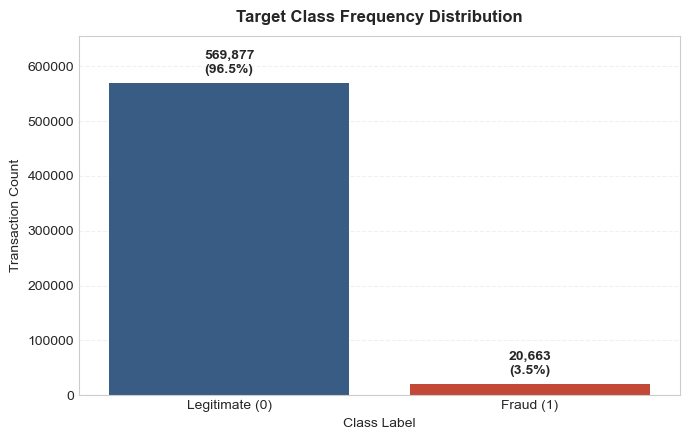

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))

df_plot_target = target_dist.to_pandas()

sns.barplot(data=df_plot_target, x='label', y='count', palette=PALETTE_PAIR, ax=ax)
ax.set_title('Target Class Frequency Distribution', fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Transaction Count', fontsize=10)
ax.set_xlabel('Class Label', fontsize=10)
ax.set_ylim(0, df_plot_target['count'].max() * 1.15)

for i, row in df_plot_target.iterrows():
    ax.annotate(f"{row['count']:,}\n({row['percentage']}%)",
                (i, row['count']),
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
save_fig(fig, 'fig02_target_class_distribution.png')
plt.show()

---
## 5. Univariate Exploratory Data Analysis
Profile monetary volume, selected counter/timedelta numerical distributions, and primary categorical frequencies.

=== TransactionAmt Summary Statistics ===
Count:       590,540
Mean:        135.03
Std Dev:     239.16
Min:         0.25
25th Pct:    43.32
Median:      68.77
75th Pct:    125.00
99th Pct:    1104.00
Max:         31937.39
Skewness:    14.37


[Saved Plot] -> output\figures\fig03_transaction_amount_distributions.png


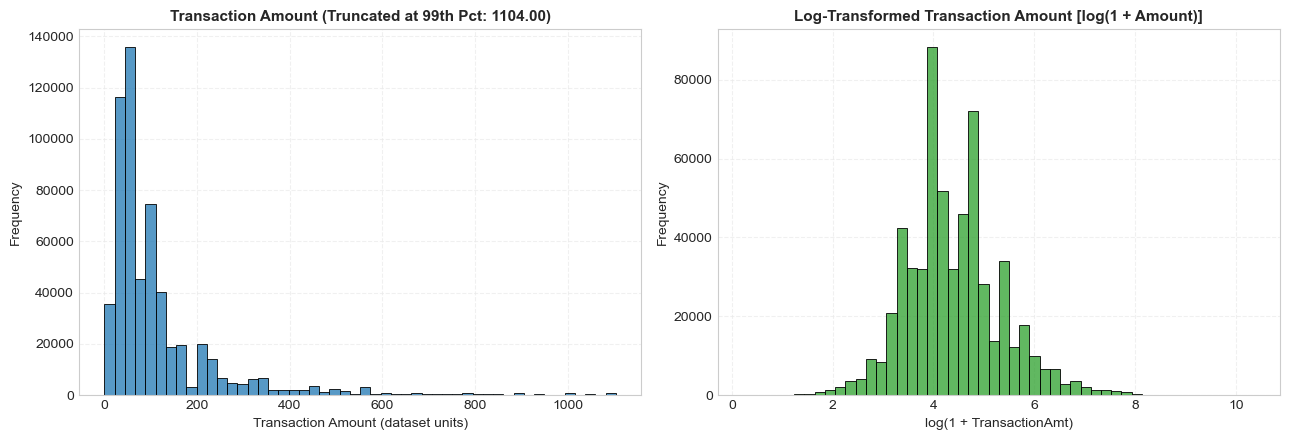

In [15]:
amt_s = train_tx['TransactionAmt']

print("=== TransactionAmt Summary Statistics ===")
print(f"Count:       {amt_s.len():,}")
print(f"Mean:        {amt_s.mean():.2f}")
print(f"Std Dev:     {amt_s.std():.2f}")
print(f"Min:         {amt_s.min():.2f}")
print(f"25th Pct:    {amt_s.quantile(0.25):.2f}")
print(f"Median:      {amt_s.median():.2f}")
print(f"75th Pct:    {amt_s.quantile(0.75):.2f}")
print(f"99th Pct:    {amt_s.quantile(0.99):.2f}")
print(f"Max:         {amt_s.max():.2f}")
print(f"Skewness:    {amt_s.skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

amt_np = amt_s.to_numpy()

# Raw distribution up to 99th percentile
p99 = amt_s.quantile(0.99)
sns.histplot(amt_np[amt_np <= p99], bins=50, color=COLOR_PRIMARY, ax=axes[0])
axes[0].set_title(f'Transaction Amount (Truncated at 99th Pct: {p99:.2f})', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Transaction Amount (dataset units)')
axes[0].set_ylabel('Frequency')

# Log-Transformed Distribution
sns.histplot(np.log1p(amt_np), bins=50, color='#2CA02C', ax=axes[1])
axes[1].set_title('Log-Transformed Transaction Amount [log(1 + Amount)]', fontsize=11, fontweight='bold')
axes[1].set_xlabel('log(1 + TransactionAmt)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
save_fig(fig, 'fig03_transaction_amount_distributions.png')
plt.show()

### 5.1 Representative Numerical Feature Distributions
Inspect distributions of key numerical features (`dist1` distance estimation and `D15` timedelta).

[Saved Plot] -> output\figures\fig04_numerical_dist1_d15.png


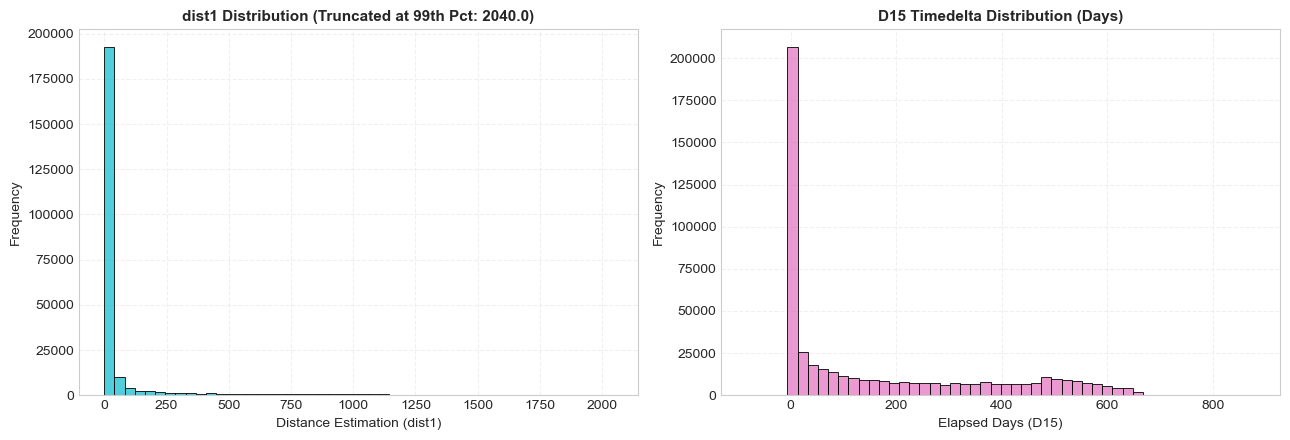

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# dist1 distribution (filtered non-null, capped at 99th percentile)
dist1_clean = train_tx['dist1'].drop_nulls()
p99_dist1 = dist1_clean.quantile(0.99)
sns.histplot(dist1_clean.filter(dist1_clean <= p99_dist1).to_numpy(), bins=50, color='#17BECF', ax=axes[0])
axes[0].set_title(f'dist1 Distribution (Truncated at 99th Pct: {p99_dist1:.1f})', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Distance Estimation (dist1)')
axes[0].set_ylabel('Frequency')

# D15 distribution (filtered non-null)
d15_clean = train_tx['D15'].drop_nulls().to_numpy()
sns.histplot(d15_clean, bins=50, color='#E377C2', ax=axes[1])
axes[1].set_title('D15 Timedelta Distribution (Days)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Elapsed Days (D15)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
save_fig(fig, 'fig04_numerical_dist1_d15.png')
plt.show()

### 5.2 Key Categorical Modality Distributions
Analyze modality frequencies across `ProductCD`, `card4`, `card6`, and top purchaser email domains.

[Saved Plot] -> output\figures\fig05_categorical_distributions.png


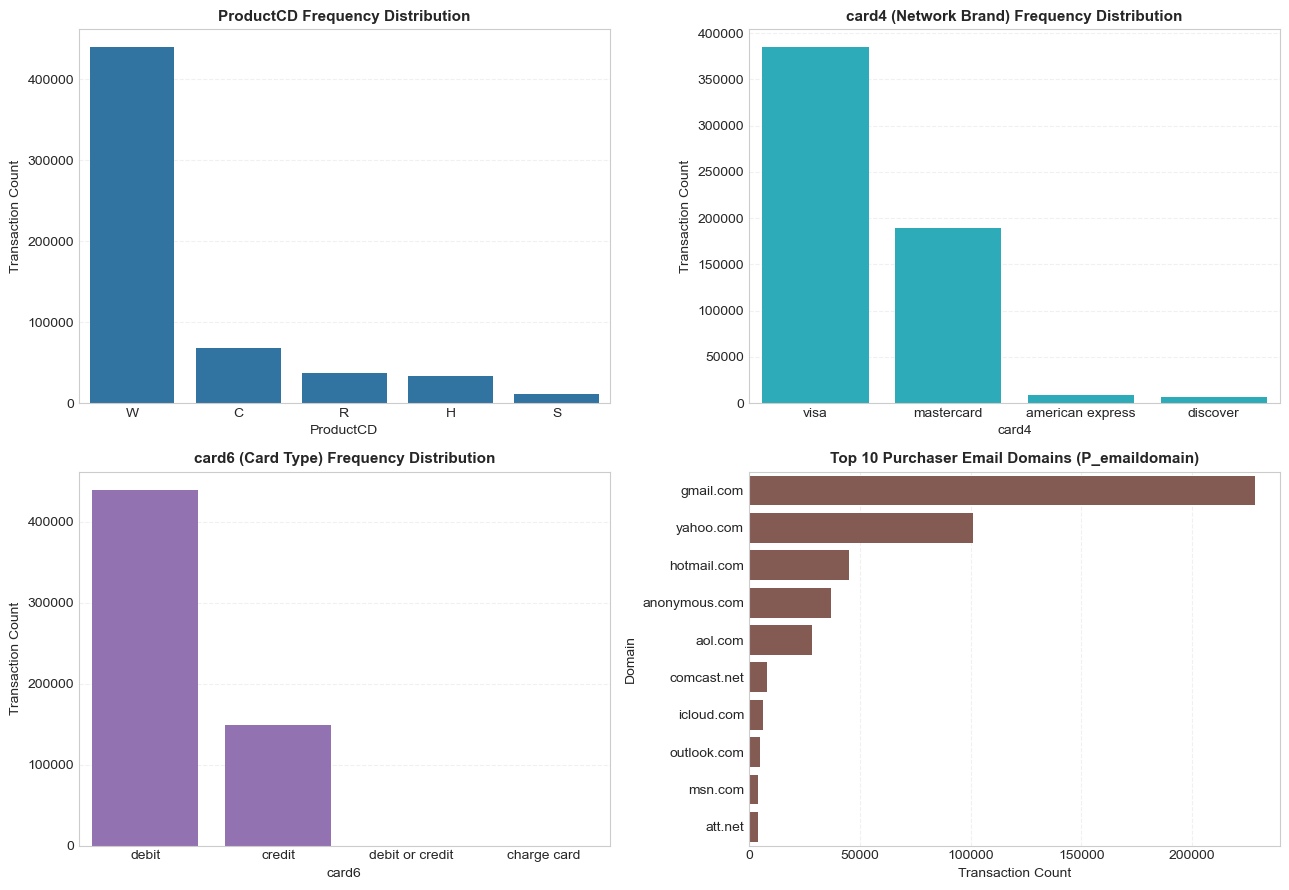

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. ProductCD
prod_pd = train_tx['ProductCD'].value_counts().sort('count', descending=True).to_pandas()
sns.barplot(data=prod_pd, x='ProductCD', y='count', color=COLOR_PRIMARY, ax=axes[0, 0])
axes[0, 0].set_title('ProductCD Frequency Distribution', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Transaction Count')

# 2. Card4 (Network)
card4_pd = train_tx['card4'].drop_nulls().value_counts().sort('count', descending=True).to_pandas()
sns.barplot(data=card4_pd, x='card4', y='count', color='#17BECF', ax=axes[0, 1])
axes[0, 1].set_title('card4 (Network Brand) Frequency Distribution', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Transaction Count')

# 3. Card6 (Type)
card6_pd = train_tx['card6'].drop_nulls().value_counts().sort('count', descending=True).to_pandas()
sns.barplot(data=card6_pd, x='card6', y='count', color='#9467BD', ax=axes[1, 0])
axes[1, 0].set_title('card6 (Card Type) Frequency Distribution', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Transaction Count')

# 4. Top 10 P_emaildomain
email_pd = train_tx['P_emaildomain'].drop_nulls().value_counts().sort('count', descending=True).head(10).to_pandas()
sns.barplot(data=email_pd, y='P_emaildomain', x='count', color='#8C564B', ax=axes[1, 1])
axes[1, 1].set_title('Top 10 Purchaser Email Domains (P_emaildomain)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Transaction Count')
axes[1, 1].set_ylabel('Domain')

plt.tight_layout()
save_fig(fig, 'fig05_categorical_distributions.png')
plt.show()

---
## 6. Fraud vs. Legitimate Analysis
Compare behavior and empirical fraud rates across amounts, missingness patterns, products, cards, devices, email channels, and identity records.

=== Transaction Amount Comparison ===
Legitimate Mean:   134.51  |  Median: 68.50  |  75th Pct: 120.00
Fraudulent Mean:   149.24  |  Median: 75.00  |  75th Pct: 161.00


[Saved Plot] -> output\figures\fig06_amount_fraud_vs_legit.png


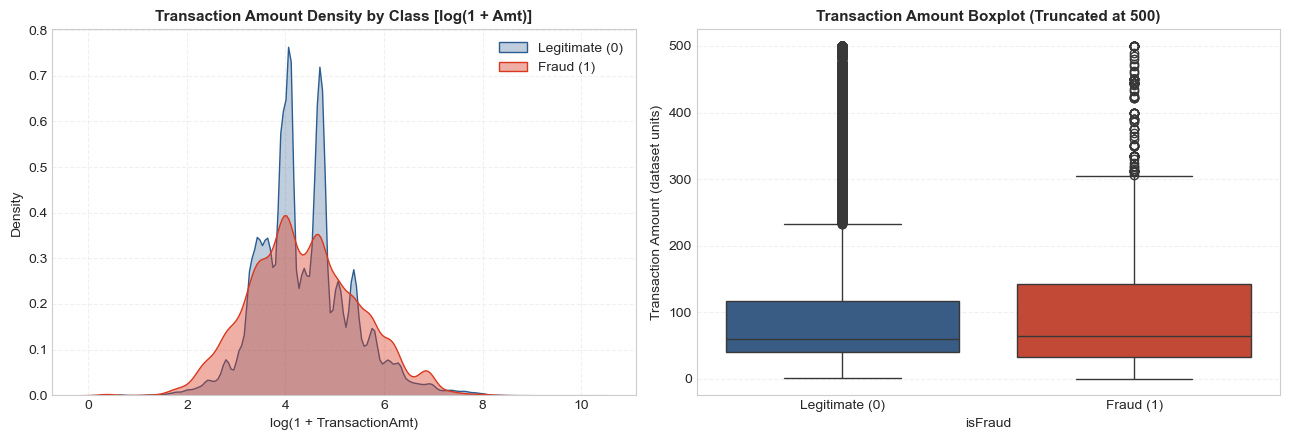

In [18]:
amt_legit = train_tx.filter(pl.col('isFraud') == 0)['TransactionAmt']
amt_fraud = train_tx.filter(pl.col('isFraud') == 1)['TransactionAmt']

print("=== Transaction Amount Comparison ===")
print(f"Legitimate Mean:   {amt_legit.mean():.2f}  |  Median: {amt_legit.median():.2f}  |  75th Pct: {amt_legit.quantile(0.75):.2f}")
print(f"Fraudulent Mean:   {amt_fraud.mean():.2f}  |  Median: {amt_fraud.median():.2f}  |  75th Pct: {amt_fraud.quantile(0.75):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Log-Transformed KDE comparison
sns.kdeplot(np.log1p(amt_legit.to_numpy()), label='Legitimate (0)', color=COLOR_LEGIT, fill=True, alpha=0.3, ax=axes[0])
sns.kdeplot(np.log1p(amt_fraud.to_numpy()), label='Fraud (1)', color=COLOR_FRAUD, fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title('Transaction Amount Density by Class [log(1 + Amt)]', fontsize=11, fontweight='bold')
axes[0].set_xlabel('log(1 + TransactionAmt)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Boxplot comparison (capped at 500 for clean visualization)
sample_amt = (
    train_tx
    .filter(pl.col('TransactionAmt') <= 500)
    .select(['isFraud', 'TransactionAmt'])
    .sample(n=50000, seed=RANDOM_SEED)
    .to_pandas()
)
sns.boxplot(data=sample_amt, x='isFraud', y='TransactionAmt', palette=PALETTE_PAIR, ax=axes[1])
axes[1].set_title('Transaction Amount Boxplot (Truncated at 500)', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[1].set_ylabel('Transaction Amount (dataset units)')

plt.tight_layout()
save_fig(fig, 'fig06_amount_fraud_vs_legit.png')
plt.show()

### 6.1 Missingness Comparison: Legitimate vs. Fraud
Evaluate whether missingness rates on key sparse features differ between legitimate and fraudulent transactions.

In [19]:
sparse_check_cols = ['dist1', 'dist2', 'D7', 'D13', 'D14', 'R_emaildomain']
miss_comp_records = []

n_leg = train_tx.filter(pl.col('isFraud') == 0).height
n_frd = train_tx.filter(pl.col('isFraud') == 1).height

for col in sparse_check_cols:
    if col in train_tx.columns:
        m_leg = (train_tx.filter(pl.col('isFraud') == 0)[col].null_count() / n_leg) * 100
        m_frd = (train_tx.filter(pl.col('isFraud') == 1)[col].null_count() / n_frd) * 100
        miss_comp_records.append({
            'Feature': col,
            'Missing % (Legit)': round(m_leg, 2),
            'Missing % (Fraud)': round(m_frd, 2),
            'Difference (pp)': round(m_frd - m_leg, 2)
        })

df_miss_comp = pl.DataFrame(miss_comp_records).sort('Difference (pp)', descending=True)
print("=== Missingness Comparison: Legitimate vs. Fraud ===")
print(df_miss_comp)

=== Missingness Comparison: Legitimate vs. Fraud ===
shape: (6, 4)
┌───────────────┬───────────────────┬───────────────────┬─────────────────┐
│ Feature       ┆ Missing % (Legit) ┆ Missing % (Fraud) ┆ Difference (pp) │
│ ---           ┆ ---               ┆ ---               ┆ ---             │
│ str           ┆ f64               ┆ f64               ┆ f64             │
╞═══════════════╪═══════════════════╪═══════════════════╪═════════════════╡
│ dist1         ┆ 59.02             ┆ 76.99             ┆ 17.96           │
│ dist2         ┆ 94.05             ┆ 81.94             ┆ -12.11          │
│ D7            ┆ 94.19             ┆ 71.98             ┆ -22.21          │
│ D13           ┆ 90.33             ┆ 66.91             ┆ -23.42          │
│ D14           ┆ 90.35             ┆ 65.09             ┆ -25.26          │
│ R_emaildomain ┆ 77.88             ┆ 45.67             ┆ -32.21          │
└───────────────┴───────────────────┴───────────────────┴─────────────────┘


### 6.2 Empirical Fraud Rate by `ProductCD`
Evaluate fraud risk concentration across product checkout categories.

=== Fraud Rate by ProductCD ===
shape: (5, 4)
┌───────────┬──────────┬──────────┬────────────────┐
│ ProductCD ┆ total_tx ┆ fraud_tx ┆ fraud_rate_pct │
│ ---       ┆ ---      ┆ ---      ┆ ---            │
│ str       ┆ u32      ┆ i64      ┆ f64            │
╞═══════════╪══════════╪══════════╪════════════════╡
│ W         ┆ 439670   ┆ 8969     ┆ 2.04           │
│ C         ┆ 68519    ┆ 8008     ┆ 11.69          │
│ R         ┆ 37699    ┆ 1426     ┆ 3.78           │
│ H         ┆ 33024    ┆ 1574     ┆ 4.77           │
│ S         ┆ 11628    ┆ 686      ┆ 5.9            │
└───────────┴──────────┴──────────┴────────────────┘


[Saved Plot] -> output\figures\fig07_fraud_rate_by_product.png


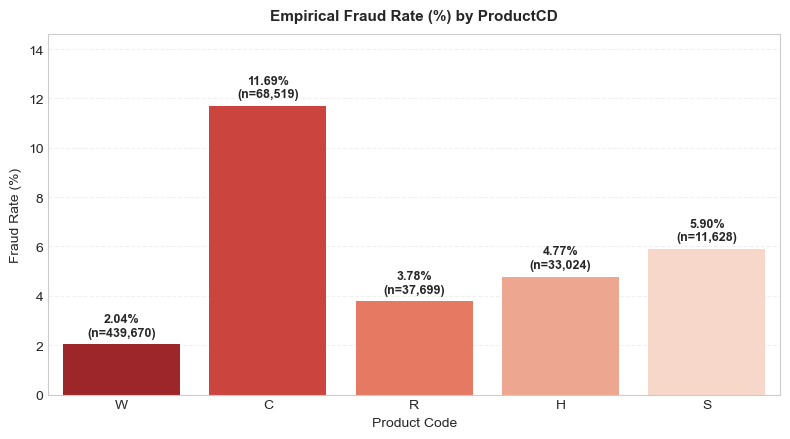

In [20]:
prod_fraud = (
    train_tx
    .group_by('ProductCD')
    .agg([
        pl.col('isFraud').count().alias('total_tx'),
        pl.col('isFraud').sum().alias('fraud_tx'),
        (pl.col('isFraud').mean() * 100).round(2).alias('fraud_rate_pct')
    ])
    .sort('total_tx', descending=True)
)

print("=== Fraud Rate by ProductCD ===")
print(prod_fraud)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=prod_fraud.to_pandas(), x='ProductCD', y='fraud_rate_pct', palette='Reds_r', ax=ax)
ax.set_title('Empirical Fraud Rate (%) by ProductCD', fontsize=11, fontweight='bold', pad=10)
ax.set_ylabel('Fraud Rate (%)')
ax.set_xlabel('Product Code')
ax.set_ylim(0, prod_fraud['fraud_rate_pct'].max() * 1.25)

for i, row in enumerate(prod_fraud.iter_rows(named=True)):
    ax.annotate(f"{row['fraud_rate_pct']:.2f}%\n(n={row['total_tx']:,})",
                (i, row['fraud_rate_pct']),
                ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 4),
                textcoords='offset points')

plt.tight_layout()
save_fig(fig, 'fig07_fraud_rate_by_product.png')
plt.show()

### 6.3 Fraud Rates by Card Network & Card Type
Examine fraud prevalence across card brands (`card4`) and payment instruments (`card6`) with minimum support filtering.

[Saved Plot] -> output\figures\fig08_fraud_rate_by_card.png


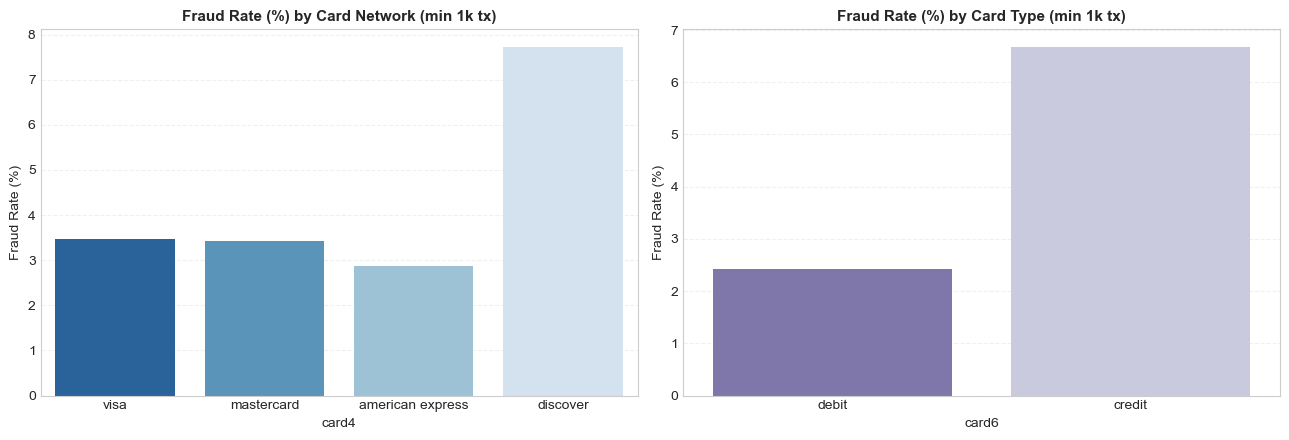

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Card4 (Brand)
card4_fraud = (
    train_tx
    .filter(pl.col('card4').is_not_null())
    .group_by('card4')
    .agg([
        pl.col('isFraud').count().alias('total_tx'),
        (pl.col('isFraud').mean() * 100).round(2).alias('fraud_rate_pct')
    ])
    .filter(pl.col('total_tx') >= 1000) # Support filter
    .sort('total_tx', descending=True)
)

sns.barplot(data=card4_fraud.to_pandas(), x='card4', y='fraud_rate_pct', palette='Blues_r', ax=axes[0])
axes[0].set_title('Fraud Rate (%) by Card Network (min 1k tx)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')

# Card6 (Type)
card6_fraud = (
    train_tx
    .filter(pl.col('card6').is_not_null())
    .group_by('card6')
    .agg([
        pl.col('isFraud').count().alias('total_tx'),
        (pl.col('isFraud').mean() * 100).round(2).alias('fraud_rate_pct')
    ])
    .filter(pl.col('total_tx') >= 1000) # Support filter
    .sort('total_tx', descending=True)
)

sns.barplot(data=card6_fraud.to_pandas(), x='card6', y='fraud_rate_pct', palette='Purples_r', ax=axes[1])
axes[1].set_title('Fraud Rate (%) by Card Type (min 1k tx)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
save_fig(fig, 'fig08_fraud_rate_by_card.png')
plt.show()

### 6.4 Fraud Rates Across Device Channels & Email Match Status
Assess observed fraud prevalence across device categories and purchaser-recipient domain matching ($P_\text{email} == R_\text{email}$).

=== Fraud Rate by Device Category ===
shape: (3, 3)
┌───────────────────────┬──────────┬────────────────┐
│ device_category       ┆ total_tx ┆ fraud_rate_pct │
│ ---                   ┆ ---      ┆ ---            │
│ str                   ┆ u32      ┆ f64            │
╞═══════════════════════╪══════════╪════════════════╡
│ No Identity / Unknown ┆ 449730   ┆ 2.1            │
│ desktop               ┆ 85165    ┆ 6.52           │
│ mobile                ┆ 55645    ┆ 10.17          │
└───────────────────────┴──────────┴────────────────┘

=== Fraud Rate by Email Domain Match Status ===
shape: (2, 4)
┌───────────────┬──────────┬────────────────┬────────────────────────┐
│ domains_match ┆ total_tx ┆ fraud_rate_pct ┆ match_status           │
│ ---           ┆ ---      ┆ ---            ┆ ---                    │
│ bool          ┆ u32      ┆ f64            ┆ str                    │
╞═══════════════╪══════════╪════════════════╪════════════════════════╡
│ false         ┆ 23723    ┆ 2.87           

[Saved Plot] -> output\figures\fig09_fraud_rate_device_and_email.png


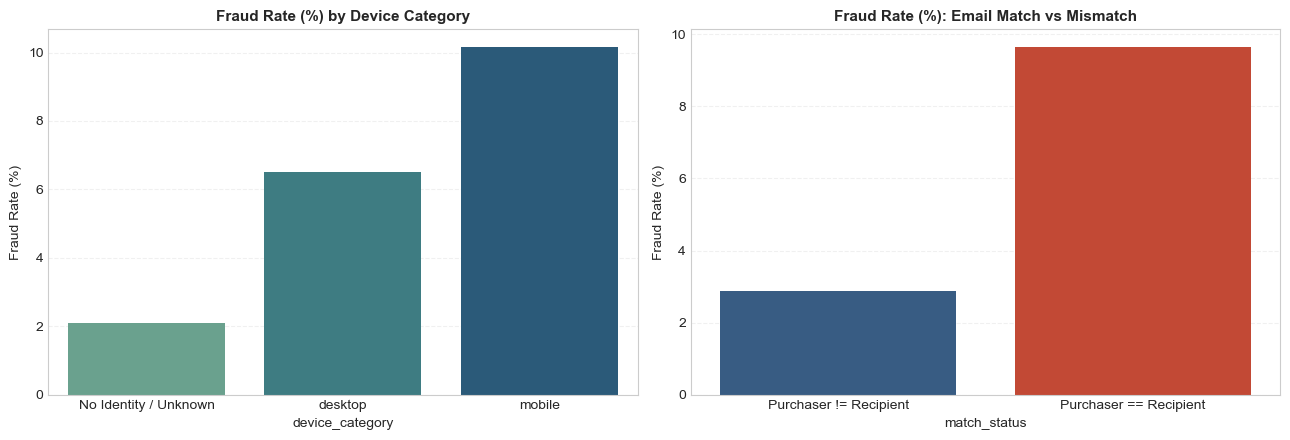

In [22]:
# Join DeviceType from train_identity
df_dev = (
    train_tx
    .select(['TransactionID', 'isFraud', 'P_emaildomain', 'R_emaildomain'])
    .join(train_id.select(['TransactionID', 'DeviceType']), on='TransactionID', how='left')
    .with_columns(pl.col('DeviceType').fill_null('No Identity / Unknown').alias('device_category'))
)

dev_fraud = (
    df_dev
    .group_by('device_category')
    .agg([
        pl.col('isFraud').count().alias('total_tx'),
        (pl.col('isFraud').mean() * 100).round(2).alias('fraud_rate_pct')
    ])
    .sort('total_tx', descending=True)
)

print("=== Fraud Rate by Device Category ===")
print(dev_fraud)

# Email Match vs Mismatch
email_match = (
    df_dev
    .filter(pl.col('P_emaildomain').is_not_null() & pl.col('R_emaildomain').is_not_null())
    .with_columns((pl.col('P_emaildomain') == pl.col('R_emaildomain')).alias('domains_match'))
    .group_by('domains_match')
    .agg([
        pl.col('isFraud').count().alias('total_tx'),
        (pl.col('isFraud').mean() * 100).round(2).alias('fraud_rate_pct')
    ])
    .with_columns(
        pl.when(pl.col('domains_match') == True)
        .then(pl.lit('Purchaser == Recipient'))
        .otherwise(pl.lit('Purchaser != Recipient'))
        .alias('match_status')
    )
)

print("\n=== Fraud Rate by Email Domain Match Status ===")
print(email_match)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=dev_fraud.to_pandas(), x='device_category', y='fraud_rate_pct', palette='crest', ax=axes[0])
axes[0].set_title('Fraud Rate (%) by Device Category', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')

sns.barplot(data=email_match.to_pandas(), x='match_status', y='fraud_rate_pct', palette=[COLOR_LEGIT, COLOR_FRAUD], ax=axes[1])
axes[1].set_title('Fraud Rate (%): Email Match vs Mismatch', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
save_fig(fig, 'fig09_fraud_rate_device_and_email.png')
plt.show()

### 6.5 Identity Availability as an Observed Risk Association
Measure the fraud prevalence disparity between transactions with vs. without attached identity records.

=== Identity Record Availability vs. Fraud Risk ===
shape: (2, 5)
┌────────┬──────────┬──────────┬────────────────┬──────────────────┐
│ has_id ┆ total_tx ┆ fraud_tx ┆ fraud_rate_pct ┆ status           │
│ ---    ┆ ---      ┆ ---      ┆ ---            ┆ ---              │
│ i32    ┆ u32      ┆ i64      ┆ f64            ┆ str              │
╞════════╪══════════╪══════════╪════════════════╪══════════════════╡
│ 1      ┆ 144233   ┆ 11318    ┆ 7.85           ┆ Identity Present │
│ 0      ┆ 446307   ┆ 9345     ┆ 2.09           ┆ Identity Absent  │
└────────┴──────────┴──────────┴────────────────┴──────────────────┘

Identity Present Fraud Rate: 7.85%
Identity Absent Fraud Rate:  2.09%
Relative Risk Ratio:         3.76x higher fraud prevalence when identity record is attached.
[Saved Plot] -> output\figures\fig10_identity_availability_risk.png


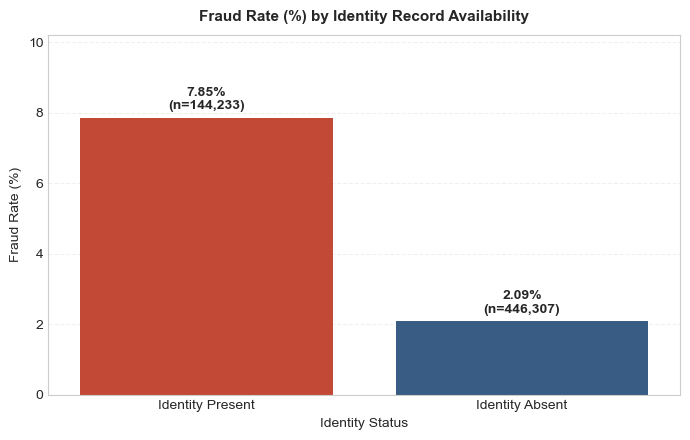

In [23]:
id_risk = (
    train_tx
    .select(['TransactionID', 'isFraud'])
    .join(train_id.select('TransactionID').with_columns(pl.lit(1).alias('has_id')), on='TransactionID', how='left')
    .with_columns(pl.col('has_id').fill_null(0))
    .group_by('has_id')
    .agg([
        pl.col('isFraud').count().alias('total_tx'),
        pl.col('isFraud').sum().alias('fraud_tx'),
        (pl.col('isFraud').mean() * 100).round(2).alias('fraud_rate_pct')
    ])
    .with_columns(
        pl.when(pl.col('has_id') == 1).then(pl.lit('Identity Present')).otherwise(pl.lit('Identity Absent')).alias('status')
    )
    .sort('has_id', descending=True)
)

print("=== Identity Record Availability vs. Fraud Risk ===")
print(id_risk)

rate_pres = id_risk.filter(pl.col('has_id') == 1)['fraud_rate_pct'][0]
rate_abs = id_risk.filter(pl.col('has_id') == 0)['fraud_rate_pct'][0]
rel_risk = rate_pres / rate_abs

print(f"\nIdentity Present Fraud Rate: {rate_pres:.2f}%")
print(f"Identity Absent Fraud Rate:  {rate_abs:.2f}%")
print(f"Relative Risk Ratio:         {rel_risk:.2f}x higher fraud prevalence when identity record is attached.")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=id_risk.to_pandas(), x='status', y='fraud_rate_pct', palette=[COLOR_FRAUD, COLOR_LEGIT], ax=ax)
ax.set_title('Fraud Rate (%) by Identity Record Availability', fontsize=11, fontweight='bold', pad=10)
ax.set_ylabel('Fraud Rate (%)')
ax.set_xlabel('Identity Status')
ax.set_ylim(0, id_risk['fraud_rate_pct'].max() * 1.3)

for i, row in enumerate(id_risk.iter_rows(named=True)):
    ax.annotate(f"{row['fraud_rate_pct']:.2f}%\n(n={row['total_tx']:,})",
                (i, row['fraud_rate_pct']),
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 4),
                textcoords='offset points')

plt.tight_layout()
save_fig(fig, 'fig10_identity_availability_risk.png')
plt.show()

---
## 7. Temporal EDA
Analyze relative elapsed timeline, daily volume trends, 7-day rolling fraud rate, and the chronological train/test split.

=== Temporal Timeline Audit ===
Train Timeline: Day 0.00 to Day 182.00 (~6.0 months, 590,540 tx)
Gap (Train -> Test): 30.00 days
Test Timeline:  Day 212.00 to Day 395.00 (~6.0 months, 506,691 tx)


[Saved Plot] -> output\figures\fig11_temporal_volume_and_fraud_rate.png


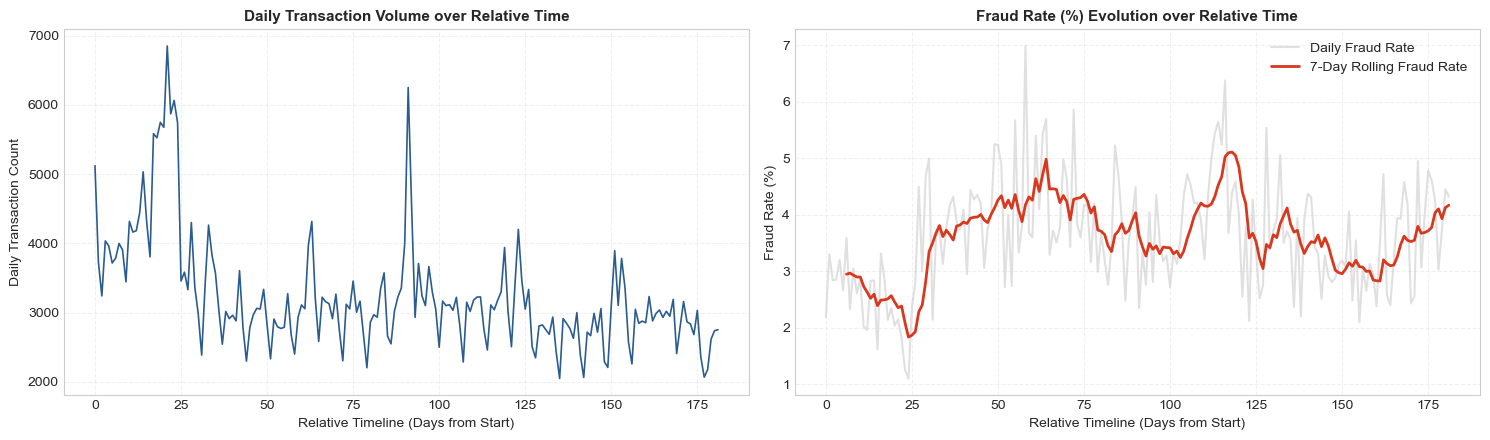

In [24]:
# 1. Timeline Duration Audit
min_trn_dt = train_tx['TransactionDT'].min()
max_trn_dt = train_tx['TransactionDT'].max()
min_tst_dt = test_tx['TransactionDT'].min()
max_tst_dt = test_tx['TransactionDT'].max()

trn_days = (max_trn_dt - min_trn_dt) / 86400
tst_days = (max_tst_dt - min_tst_dt) / 86400
gap_days = (min_tst_dt - max_trn_dt) / 86400

print("=== Temporal Timeline Audit ===")
print(f"Train Timeline: Day 0.00 to Day {trn_days:.2f} (~{trn_days/30.4:.1f} months, {train_tx.height:,} tx)")
print(f"Gap (Train -> Test): {gap_days:.2f} days")
print(f"Test Timeline:  Day {(min_tst_dt - min_trn_dt)/86400:.2f} to Day {(max_tst_dt - min_trn_dt)/86400:.2f} (~{tst_days/30.4:.1f} months, {test_tx.height:,} tx)")

# 2. Daily Aggregation & Rolling Fraud Rate
daily_tx = (
    train_tx
    .with_columns(((pl.col('TransactionDT') - min_trn_dt) // 86400).cast(pl.Int32).alias('relative_day'))
    .group_by('relative_day')
    .agg([
        pl.col('isFraud').count().alias('daily_volume'),
        pl.col('isFraud').sum().alias('daily_fraud'),
        (pl.col('isFraud').mean() * 100).round(2).alias('daily_fraud_rate')
    ])
    .sort('relative_day')
    .with_columns(
        pl.col('daily_fraud_rate').rolling_mean(window_size=7).alias('rolling_7d_fraud_rate')
    )
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

df_daily_pd = daily_tx.to_pandas()

# Plot 1: Daily Volume
axes[0].plot(df_daily_pd['relative_day'], df_daily_pd['daily_volume'], color=COLOR_LEGIT, linewidth=1.2)
axes[0].set_title('Daily Transaction Volume over Relative Time', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Relative Timeline (Days from Start)')
axes[0].set_ylabel('Daily Transaction Count')

# Plot 2: Daily and 7-Day Rolling Fraud Rate
axes[1].plot(df_daily_pd['relative_day'], df_daily_pd['daily_fraud_rate'], color='#CCCCCC', alpha=0.6, label='Daily Fraud Rate')
axes[1].plot(df_daily_pd['relative_day'], df_daily_pd['rolling_7d_fraud_rate'], color=COLOR_FRAUD, linewidth=2.0, label='7-Day Rolling Fraud Rate')
axes[1].set_title('Fraud Rate (%) Evolution over Relative Time', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Relative Timeline (Days from Start)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].legend()

plt.tight_layout()
save_fig(fig, 'fig11_temporal_volume_and_fraud_rate.png')
plt.show()

### 7.1 Chronological Split Implications
Because test transactions occur chronologically after training (Day ~213 to ~395 vs Day 0 to ~182), the temporal structure strongly supports using an Out-of-Time (OOT) validation strategy.

---
## 8. Key Findings & Notebook 2 Handoff
Summary of core empirical observations and candidate directions to investigate in Notebook 2:
1. **Target Imbalance (3.50%)**: Prioritize PR-AUC, precision, recall, and business-aware false-positive cost over raw accuracy.
2. **Missingness Signals**: Investigate whether missingness indicator flags improve predictive performance without discarding sparse informative columns.
3. **High-Cardinality Categoricals**: Evaluate frequency encoding and leakage-safe target encoding where appropriate for features like `DeviceInfo` and `card1`.
4. **Transaction Amount**: Investigate whether a log-transformed amount and cents fraction features improve model performance.
5. **Identity Signal**: Investigate identity availability indicators and selected identity/device-derived features.
6. **Temporal Structure**: Use a time-aware validation strategy consistent with the transaction timeline.